# Preliminary setups


In [5]:
!pip install langchain_experimental
!pip install langchain-groq
!pip install ipykernel
!python -m ipykernel install --user --name=medical-agents --display-name "DANA system"

  Using cached langchain_experimental-0.4.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached aiohappyeyeballs-2.7.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached langchain_text_splitters-1.1.2-py3-none-any.whl.metadata (3.3 kB)
  Using cached langchain_protocol-0.0.18-py3-none-any.whl.metadata (2.4 kB)
Using cached langchain_experimental-0.4.2-py3-none-any.whl (211 kB)
Using cached langchain_community-0.4.2-py3-none-any.whl (2.4 MB)
Using cached httpx_sse-0.4.3-py3-none-any.whl (9.0 kB)
Using cached langchain_classic-1.0.8-py3-none-any.whl (1.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 7.6 MB/s  0:00:00
Using cached langc

Here we define our api keys etc

In [6]:
import getpass
import os

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Provide your {var}")

_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("TAVILY_API_KEY")
_set_if_undefined("GROQ_API_KEY")

Provide your OPENAI_API_KEY ········
Provide your TAVILY_API_KEY ········
Provide your GROQ_API_KEY ········


In [7]:
!pip install -U langgraph langchain-core langchain-community langchain-tavily langchain_openai langchain-anthropic langchain_google_genai

  Using cached langchain_tavily-0.2.18-py3-none-any.whl.metadata (20 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached docstring_parser-0.18.0-py3-none-any.whl.metadata (3.5 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyasn1-0.6.4-py3-none-any.whl.metadata (8.4 kB)
Using cached langgraph_sdk-0.4.2-py3-none-any.whl (160 kB)
Using cached langchain_tavily-0.2.18-py3-none-any.whl (30 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 23.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.6 MB/s  0:00:00
Using cached docstring_parser-0.18.0-py3-none-any.whl (22 kB)
Using cached filetype-1.2.0-py2.py3-none-any.whl (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.6 MB/s  0:00:00
Using cached pyasn1_modules-0.4.2-py3-no

# All imports

The imports needed in this system to make sure we have our packages in place and it works 

In [8]:
from typing import Annotated, List, Dict, Optional, Literal, TypedDict
import os
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.language_models import BaseChatModel
from langgraph.types import Command
from langchain_tavily import TavilySearch
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langchain_experimental.utilities import PythonREPL
from langchain_groq import ChatGroq

/var/folders/rp/bltyyw817g9593kj_7pxytnc0000gn/T/ipykernel_5221/1837860476.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.
/var/folders/rp/bltyyw817g9593kj_7pxytnc0000gn/T/ipykernel_5221/1837860476.py:13: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


# Define the tools


Define tools like web scrapping, writting a document, reading etc

In [9]:
@tool
def scrape_webpages(urls: List[str]) -> str:
    """User requests and bs4 to scrape the provided web pages for detailed information"""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n'
            f'{doc.page_content}\n'
            f'</Document>'
        ]
    )
@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections"],
    file_name: Annotated[str, "File path to save the outline"]
) -> Annotated[str, "Path of the saved outline file"]:
    """Create and save outline file"""
    os.makedirs(os.path.join(os.getcwd(), "temp"), exist_ok=True)
    file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    with open(file_to_use, "w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"

@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from"],
    start: Annotated[Optional[str], "The start line. Default is 0"] = None, 
    end: Annotated[Optional[str], "The end line. Defaul is None"] = None,
):
    """Read the specific document"""
    file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    try:
        with open(file_to_use, "r") as file:
            lines = file.readlines()
            if start is None:
                start = 0
                
            start_idx = int(start) if start and str(start).isdigit() else 0
            end_idx = int(end) if end and str(end).isdigit() else None
            
            return "".join(lines[start_idx:end_idx])
    except FileNotFoundError:
        return f"Error: Document {file_name} not found"

@tool
def write_document(
    content: Annotated[str, "Text content to be written to the document"],
    file_name: Annotated[str, "File path to save the document"]
):
    """Create and save a text document"""
    os.makedirs(os.path.join(os.getcwd(), "temp"), exist_ok=True)
    file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    with open(file_to_use, "w") as file:
        file.write(content)
    return f"Document saved to {file_name}"
                                                          

@tool
def edit_document(
    file_name: Annotated[str, "File path to save the document"],
    inserts: Annotated[Dict[str, str], "Dictionary where key is the line number and value is the text to be inserted at the line"]   
):
    """Edit a document by inserting text at specified line numbers"""
    file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    try:
        with open(file_to_use, "r") as file:
            lines = file.readlines()
    except FileNotFoundError:
        return f"Error: Document {file_name} not found."

    try:
        parsed_inserts = {int(k): v for k, v in inserts.items()}
        sorted_inserts = sorted(parsed_inserts.items())
    except ValueError:
        return "Error: All keys in the inserts dictionary must be valid numbers."

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number-1, text + "\n")
        else:
            return f"Error: line number {line_number} is out of range"
            
    with open(file_to_use, "w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

repl = PythonREPL()

@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart"]):
    """Use this to execute python code. If you want to see the output of any value,
    you should print it with `print(...)`. This is visible to the user"""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed: \n ```python \n{code}\n Stdout: {result}"
    

# Define the Supervisor

In [10]:
class State(MessagesState):
    next: str

def make_supervisor_node(llm: BaseChatModel, members: List[str]):
    options = ["FINISH"] + members
    system_prompt = (
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH"
    )
    
    class Router(TypedDict):
        next: Literal[*options]
        
    def supervisor(state: State) -> Command[Literal[*members, "__end__"]]:
        messages = [
            {"role": "system", "content": system_prompt}
        ] + state["messages"]
    
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END
        return Command(
            goto=goto, 
            update={"next": goto}
        )
    return supervisor
    

## Define the Agent Teams

### 1. Reader Agent - 

In [11]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)


tavily_tool = TavilySearch(max_results=3)

search_agent = create_react_agent(llm, tools=[tavily_tool])

def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=result["messages"][-1].content, 
                    name="search"
                )
            ]
        },
        goto = "supervisor"
    )

web_scrapper_agent = create_react_agent(llm, tools=[scrape_webpages])
    
def web_scrapper_node(state: State) -> Command[Literal["supervisor"]]:
    result = web_scrapper_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=result["messages"][-1].content, 
                    name="web_scrapper"
                )
            ]
        },
        goto = "supervisor"
    )
research_supervisor_node = make_supervisor_node(llm, ["search", "web_scrapper"])

/var/folders/rp/bltyyw817g9593kj_7pxytnc0000gn/T/ipykernel_5221/255773831.py:9: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  search_agent = create_react_agent(llm, tools=[tavily_tool])
/var/folders/rp/bltyyw817g9593kj_7pxytnc0000gn/T/ipykernel_5221/255773831.py:25: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  web_scrapper_agent = create_react_agent(llm, tools=[scrape_webpages])


In [12]:
research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scrapper", web_scrapper_node)

research_builder.add_edge(START, "supervisor")
research_graph = research_builder.compile()

### 2. Critic Agent - 

### 3. Teacher Agent - 

### 4. Obsidian Agent - 

### 5. Latex Agent - 

In [13]:
doc_writer_agent = create_react_agent(
    llm,
    tools = [write_document, edit_document, read_document],
    prompt="You can read, write and edit documents based on note taker's outlines. Don't ask follow up questions."
)

def doc_writer_node(state: State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update = {
            "messages": [
                HumanMessage(content = result["messages"][-1].content, name = "doc_writer")
            ]
        },
        goto = "supervisor",
    )
    
note_taking_agent = create_react_agent(
    llm,
    tools=[create_outline, read_document],
    prompt="You can read documents and create outlines for the document writer. Don't ask follow up questions."
)
        
def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update = {
            "messages": [
                HumanMessage(
                    content = result["messages"][-1].content,
                    name = "note_taker"
                )
            ]
        },
        goto = "supervisor",
    )

chart_generating_agent = create_react_agent (
    llm,
    tools=[read_document, python_repl_tool],
)


def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state)
    return Command(
        update = {
            "messages": [
                HumanMessage(
                    content = result["messages"][-1].content,
                    name = "chart_generator"
                )
            ]
        },
        goto = "supervisor",
    )

doc_writing_supervisor_node = make_supervisor_node(
    llm, ["doc_writer", "note_taker", "chart_generator"]
)

/var/folders/rp/bltyyw817g9593kj_7pxytnc0000gn/T/ipykernel_5221/404296440.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  doc_writer_agent = create_react_agent(
/var/folders/rp/bltyyw817g9593kj_7pxytnc0000gn/T/ipykernel_5221/404296440.py:18: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  note_taking_agent = create_react_agent(
/var/folders/rp/bltyyw817g9593kj_7pxytnc0000gn/T/ipykernel_5221/404296440.py:38: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_generating_agent = create_react

In [14]:
writing_builder = StateGraph(State) # Reconstrucción grafo
writing_builder.add_node("supervisor", doc_writing_supervisor_node)
writing_builder.add_node("doc_writer", doc_writer_node)
writing_builder.add_node("note_taker", note_taking_agent)
writing_builder.add_node("chart_generator", chart_generating_node)

writing_builder.add_edge(START, "supervisor")
writing_graph = writing_builder.compile()

In [15]:
for s in writing_graph.stream(
    {
        "messages": [
            (
            "user",
            "Write an outline for a poem about dogs and after write the poem itself and store it"
            )
        ]
    },
        {"recursion_limit":30}
        ):
        print(s)
        print("---")
    
        

{'supervisor': {'next': 'doc_writer'}}
---
{'doc_writer': {'messages': [HumanMessage(content='The poem about dogs has been written and saved. The final version of the poem is stored in the file "final_poem.txt".', additional_kwargs={}, response_metadata={}, name='doc_writer', id='3fb7bc8f-a6ca-4458-bba7-97b09efa0cbc')]}}
---
{'supervisor': {'next': '__end__'}}
---


# End-to-end Graph

## Implement the graph

In [20]:
teams_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])

def call_research_team(state:State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update = {
            "messages" : [
                HumanMessage(
                    content=response["messages"][-1].content, name="research_team"
                )
            ]
        },
        goto="supervisor"
    )

def call_writing_team(state:State) -> Command[Literal["supervisor"]]:
    response = writing_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update = {
            "messages" : [
                HumanMessage(
                    content=response["messages"][-1].content, name="writing_team"
                )
            ]
        },
        goto="supervisor"
    )


super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_writing_team)

super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()

## Visualize the graph

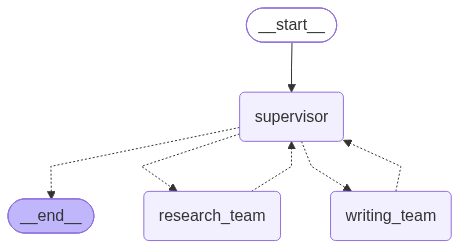

In [21]:
from IPython.display import Image, display

display(Image(super_graph.get_graph().draw_mermaid_png()))

## Run the graph

In [ ]:
for s in super_graph.stream(
    {
        "messages": [
            ("user", "Research why the gols price has been increasing crazily in 2025. Come up with reasons and compile a report")
        ]
    },
    {"recurssion_limit": 100}
):
    print(s)
    print("....")

{'supervisor': {'next': 'research_team'}}
....
{'research_team': {'messages': [HumanMessage(content='The gold price has been increasing crazily in 2025 due to various factors such as geopolitical events, inflation, and investors seeking safe-haven assets. According to Yahoo Finance, gold prices rose 64% in 2025, and experts predict that prices could hit $6,000 in 2026. The war in Iran, issues in Europe and South America, and the stock market fluctuations have contributed to the increase in gold prices. Additionally, central banks from around the world, particularly those in emerging markets, have been buying gold to hedge their currencies versus the dollar. As a result, gold has become a popular investment option, with its price rising to a new record in 2025.', additional_kwargs={}, response_metadata={}, name='research_team', id='55b9bf4d-ac42-46f9-8f16-a3b293a590ac')]}}
....
{'supervisor': {'next': 'writing_team'}}
....
